# E-commerce Customer Segmentation – Overview

- Understand customer details
- Analyze purchasing behavior
- Analyze payment and order patterns
- Analyze reviews and customer satisfaction
- Analyze location and product details
- Identify different customer segments
- Find useful customer insights

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

# Load Dataset

In [2]:
# READ/LOAD CSV FILES

customers = pd.read_csv(r"C:\Users\acer\Desktop\E-Commerce Customer Segmentation\Dataset\olist_customers_dataset.csv")
geolocation = pd.read_csv(r"C:\Users\acer\Desktop\E-Commerce Customer Segmentation\Dataset\olist_geolocation_dataset.csv")
order_item = pd.read_csv(r"C:\Users\acer\Desktop\E-Commerce Customer Segmentation\Dataset\olist_order_items_dataset.csv")
payments = pd.read_csv(r"C:\Users\acer\Desktop\E-Commerce Customer Segmentation\Dataset\olist_order_payments_dataset.csv")
reviews = pd.read_csv(r"C:\Users\acer\Desktop\E-Commerce Customer Segmentation\Dataset\olist_order_reviews_dataset.csv")
orders = pd.read_csv(r"C:\Users\acer\Desktop\E-Commerce Customer Segmentation\Dataset\olist_orders_dataset.csv")
products = pd.read_csv(r"C:\Users\acer\Desktop\E-Commerce Customer Segmentation\Dataset\olist_products_dataset.csv")
sellers = pd.read_csv(r"C:\Users\acer\Desktop\E-Commerce Customer Segmentation\Dataset\olist_sellers_dataset.csv")
category = pd.read_csv(r"C:\Users\acer\Desktop\E-Commerce Customer Segmentation\Dataset\product_category_name_translation.csv")

# Data Exploration – Overview

- View the dataset
- Check column names
- Check data types and information
- Generate statistical summary

In [3]:
# CHECK HOW MANY ROWS AND COLUMNS

print(customers.shape)
print(geolocation.shape)
print(order_item.shape)
print(payments.shape)
print(reviews.shape)
print(orders.shape)
print(products.shape)
print(sellers.shape)
print(category.shape)

(99441, 5)
(1000163, 5)
(112650, 7)
(103886, 5)
(99224, 7)
(99441, 8)
(32951, 9)
(3095, 4)
(71, 2)


In [4]:
# GET/DISPLAY ALL COLUMN NAMES

print("CUSTOMERS")
print(customers.columns.tolist())

print("GEOLOCATION")
print(geolocation.columns.tolist())

print("ORDER ITEM")
print(order_item.columns.tolist())

print("PAYMENTS")
print(payments.columns.tolist())

print("REVIEWS")
print(reviews.columns.tolist())

print("ORDERS")
print(orders.columns.tolist())

print("PRODUCTS")
print(products.columns.tolist())

print("SELLERS")
print(sellers.columns.tolist())

print("CATEGORY")
print(category.columns.tolist())

CUSTOMERS
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
GEOLOCATION
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
ORDER ITEM
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
PAYMENTS
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
REVIEWS
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
ORDERS
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
PRODUCTS
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_widt

In [5]:
# WE CHECK THE DATA TYPE OF EACH COLUMN IN THE DATASET

my_data = {
    "Customers": customers,
    "Geolocation": geolocation,
    "Order Item": order_item,
    "Payments": payments,
    "Reviews": reviews,
    "Orders": orders,
    "Products": products,
    "Sellers": sellers,
    "Category": category
}

for name, data in my_data.items():
    print("\n", name)
    print(data.dtypes)


 Customers
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

 Geolocation
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object

 Order Item
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

 Payments
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

 Reviews
review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_com

In [6]:
# INFO COLLECTS THE OVERALL INFORMATION ABOUT THE DATASET

for name, data in my_data.items():
    print("\n", name)
    data.info()


 Customers
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB

 Geolocation
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    

In [7]:
# DESCRIBE SHOWS THE STATISTICAL SUMMARY OF THE DATASET
# KEYWORD>STD=(STANDARD DEVIATION)SHOWS HOW MUCH THE DATA VARIES FROM THE AVERAGE

for name, data in my_data.items():
    print("\n", name)
    print(data.describe())


 Customers
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000

 Geolocation
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                 1.000163e+06     1.000163e+06     1.000163e+06
mean                  3.657417e+04    -2.117615e+01    -4.639054e+01
std                   3.054934e+04     5.715866e+00     4.269748e+00
min                   1.001000e+03    -3.660537e+01    -1.014668e+02
25%                   1.107500e+04    -2.360355e+01    -4.857317e+01
50%                   2.653000e+04    -2.291938e+01    -4.663788e+01
75%                   6.350400e+04    -1.997962e+01    -4.376771e+01
max                   9.999000e+04     4.506593e+01     1.211054e+02

 Order Item
       order_item_id          price  freight_value
c

# Data Cleaning and Preparation – Overview --> -->

- Check missing values
- Check duplicate values
- Check data types
- Handle missing values if needed
- Remove duplicate rows if needed
- Prepare data for analysis

In [8]:
data.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.dtypes

product_category_name            str
product_category_name_english    str
dtype: object

# Customer Analysis – Overview

- ustomer State – Customer count by state
- Customer City – Customer count by city
- Customer Distribution – Customer location distribution
- Top Locations – Top customer locations
- Customer Concentration – Areas with more customers

In [11]:
# Customers – State-wise Customer Count--top 10

customer_state = customers['customer_state'].value_counts().head(10)
customer_state

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

# "These are Brazilian State Codes"

SP → São Paulo
RJ → Rio de Janeiro
MG → Minas Gerais
RS → Rio Grande do Sul
PR → Paraná
SC → Santa Catarina
BA → Bahia
DF → Federal District
ES → Espírito Santo
GO → Goiás

In [12]:
# City Wise - customer count--top 10


customer_city = customers['customer_city'].value_counts().head(10)
customer_city

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64

In [13]:
customer_orders = orders['customer_id'].value_counts()
customer_orders.head(10)

customer_id
9ef432eb6251297304e76186b10a928d    1
b0830fb4747a6c6d20dea0b8c802d7ef    1
41ce2a54c0b03bf3443c3d931a367089    1
f88197465ea7920adcdbec7375364d82    1
8ab97904e6daea8866dbdbc4fb7aad2c    1
503740e9ca751ccdda7ba28e9ab8f608    1
ed0271e0b7da060a393796590e7b737a    1
9bdf08b4b3b52b5526ff42d37d47f222    1
f54a9f0e6b351c431402b8461ea51999    1
31ad1d1b63eb9962463f764d4e6e0c9d    1
Name: count, dtype: int64

In [14]:
customer_orders = orders['customer_id'].value_counts()
customer_orders

customer_id
9ef432eb6251297304e76186b10a928d    1
b0830fb4747a6c6d20dea0b8c802d7ef    1
41ce2a54c0b03bf3443c3d931a367089    1
f88197465ea7920adcdbec7375364d82    1
8ab97904e6daea8866dbdbc4fb7aad2c    1
                                   ..
39bd1228ee8140590ac3aca26f2dfe00    1
1fca14ff2861355f6e5f14306ff977a7    1
1aa71eb042121263aafbe80c1b562c9c    1
b331b74b18dc79bcdf6532d51e1637c1    1
edb027a75a1449115f6b43211ae02a24    1
Name: count, Length: 99441, dtype: int64

In [15]:
orders['customer_id'].nunique()

99441

In [16]:
repeat_customers = customer_orders[customer_orders > 1]
repeat_customers

Series([], Name: count, dtype: int64)

In [17]:
order_status = orders['order_status'].value_counts()
order_status

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

# Customer Order Status Analysis

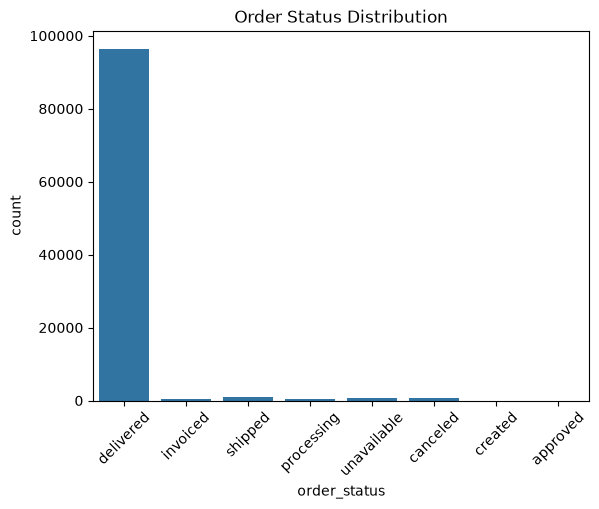

In [18]:
sns.countplot(data=orders, x='order_status')
plt.title('Order Status Distribution')
plt.xticks(rotation=45)
plt.show()

# Product Analysis

In [19]:
product_category = products['product_category_name'].value_counts().head(10)
product_category

product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

# Product Category Visualization

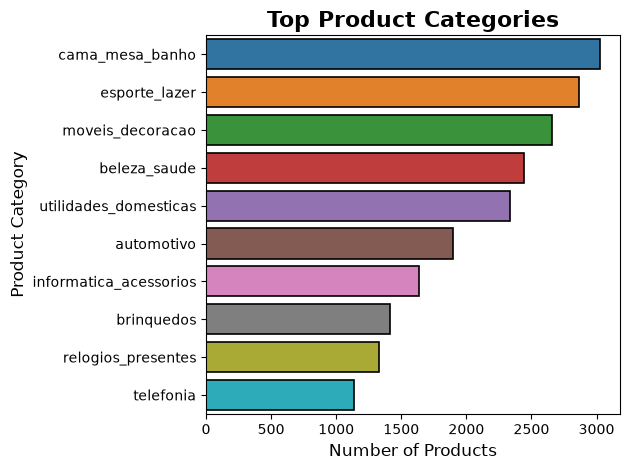

In [20]:
sns.barplot(
    x=product_category.values,
    y=product_category.index,
    hue=product_category.index,
    legend=False,
    edgecolor='black',
    linewidth=1.2
)

plt.title('Top Product Categories', fontsize=16, fontweight='bold')
plt.xlabel('Number of Products', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Product Price Analysis

In [21]:
price_summary = order_item['price'].describe()
price_summary

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

# Product Price Distribution

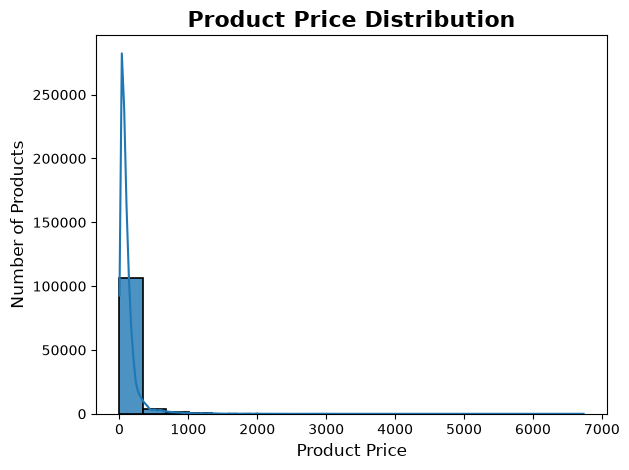

In [22]:
sns.histplot(
    data=order_item,
    x='price',
    bins=20,
    kde=True,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.8,
    stat='count'
)

plt.title('Product Price Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Product Price', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Product Weight Analaysis

In [23]:
weight_summary = products['product_weight_g'].describe()
weight_summary

count    32949.000000
mean      2276.472488
std       4282.038731
min          0.000000
25%        300.000000
50%        700.000000
75%       1900.000000
max      40425.000000
Name: product_weight_g, dtype: float64

# Product Weight Distribution

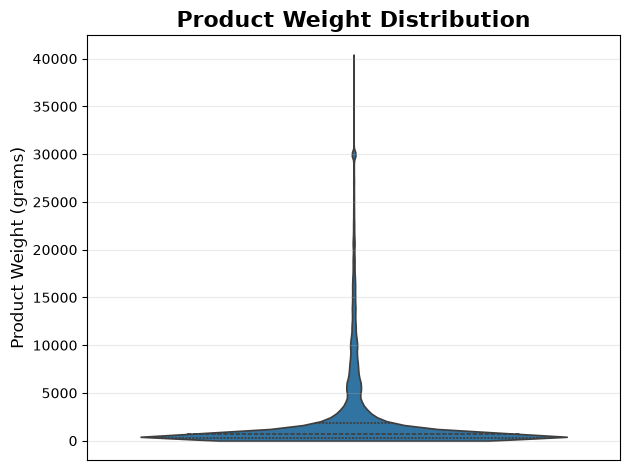

In [24]:
sns.violinplot(
    y=products['product_weight_g'],
    inner='quartile',
    cut=0,
    bw_adjust=0.6,
    density_norm='width'
)

plt.title('Product Weight Distribution', fontsize=16, fontweight='bold')
plt.ylabel('Product Weight (grams)', fontsize=12)
plt.xticks([])
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# Product Review Analysis

In [25]:
review_score = reviews['review_score'].value_counts().sort_index()
review_score

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

# Product Review Distribution

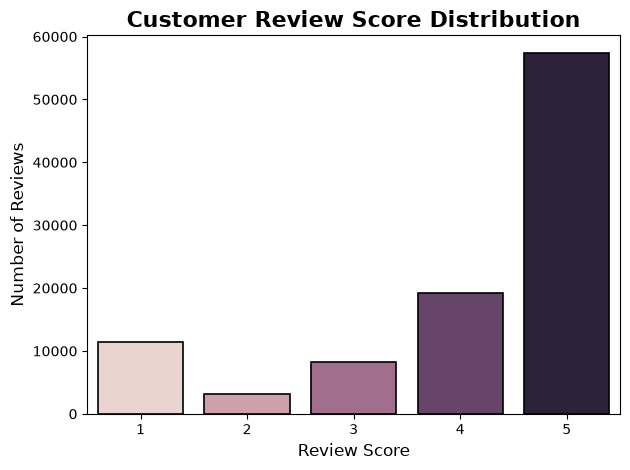

In [26]:
sns.countplot(
    data=reviews,
    x='review_score',
    hue='review_score',
    legend=False,
    edgecolor='black',
    linewidth=1.2
)

plt.title('Customer Review Score Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.tight_layout()
plt.show()

# Order & Sales Trend Analysis

In [27]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [28]:
monthly_orders = orders.groupby(
    orders['order_purchase_timestamp'].dt.to_period('M')
).size()

monthly_orders

order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64

# Monthly Sales Trend

In [29]:
sales_data = order_item.merge(
    orders[['order_id', 'order_purchase_timestamp']],
    on='order_id'
)

In [30]:
monthly_sales = sales_data.groupby(
    sales_data['order_purchase_timestamp'].dt.to_period('M')
)['price'].sum()

monthly_sales

order_purchase_timestamp
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
Freq: M, Name: price, dtype: float64

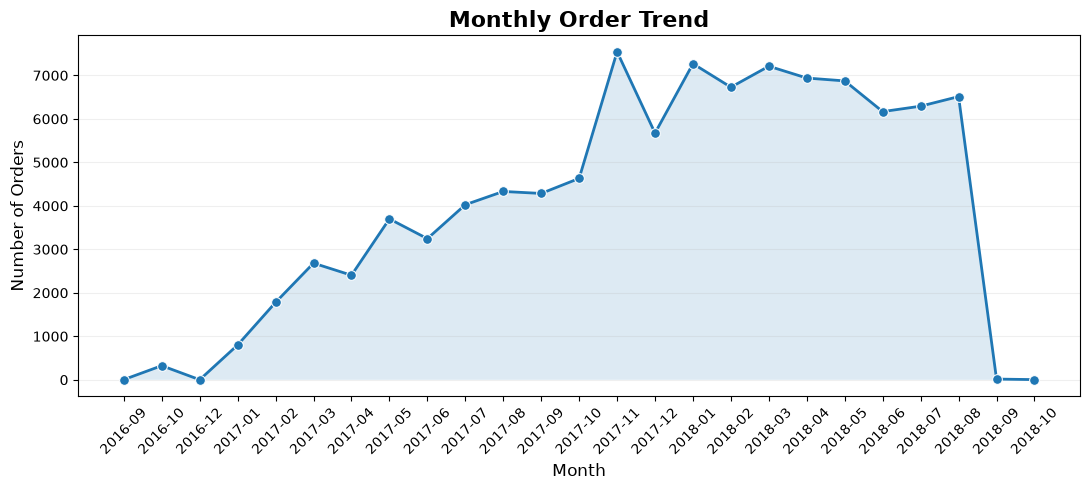

In [31]:
plt.figure(figsize=(11, 5))

sns.lineplot(
    x=monthly_orders.index.astype(str),
    y=monthly_orders.values,
    marker='o',
    markersize=7,
    linewidth=2
)

plt.fill_between(
    range(len(monthly_orders)),
    monthly_orders.values,
    alpha=0.15
)

plt.title('Monthly Order Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

plt.xticks(
    range(len(monthly_orders)),
    monthly_orders.index.astype(str),
    rotation=45
)

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# Delivery Performs Analysis

In [32]:
orders['delivery_days'] = (
    pd.to_datetime(orders['order_delivered_customer_date'])
    - pd.to_datetime(orders['order_purchase_timestamp'])
).dt.days

In [33]:
delivery_summary = orders['delivery_days'].describe()
delivery_summary

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

# Actual Delivery Date VS Estimate Delivery Date

In [34]:
delivered_orders = orders.dropna(
    subset=[
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
).copy()

In [35]:
delivered_orders['delivery_delay_days'] = (
    pd.to_datetime(delivered_orders['order_delivered_customer_date'])
    - pd.to_datetime(delivered_orders['order_estimated_delivery_date'])
).dt.days

In [36]:
delivery_status = delivered_orders['delivery_delay_days'].apply(
    lambda x: 'Early' if x < 0 else ('On Time' if x == 0 else 'Late')
)

delivery_status.value_counts()

delivery_delay_days
Early      88649
Late        6535
On Time     1292
Name: count, dtype: int64

# Average Delivery Delay

In [37]:
delivered_orders['delivery_delay_days'].mean()

np.float64(-11.876881296902857)

In [38]:
delivered_orders['delivery_status'] = delivered_orders['delivery_delay_days'].apply(
    lambda x: 'Early' if x < 0 else 'On Time' if x == 0 else 'Delayed'
)

# Delivery Performance Chart

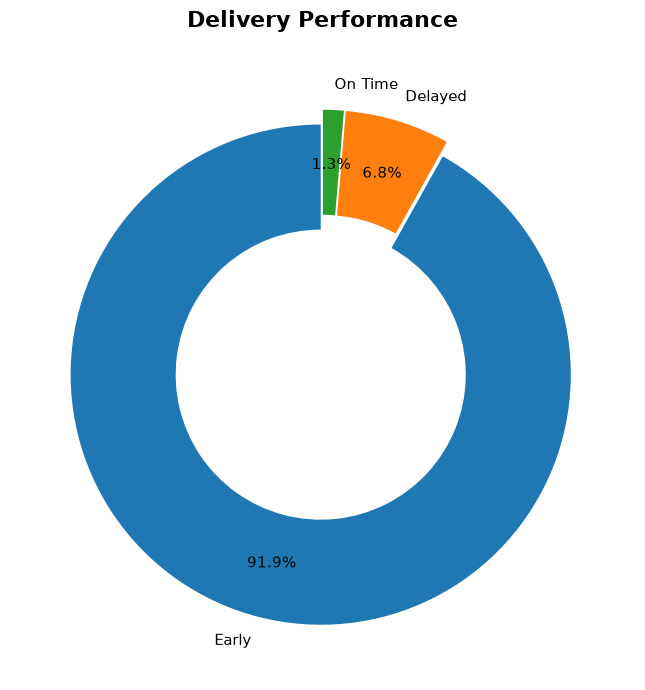

In [39]:
delivery_counts = delivered_orders['delivery_status'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    delivery_counts,
    labels=delivery_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.78,
    explode=[0.03] * len(delivery_counts),
    wedgeprops={'width': 0.42},
    textprops={'fontsize': 11}
)

plt.title(
    'Delivery Performance',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

# Payment Analysis
# Boleto>it is a Brazilian payment method used to make payments

In [40]:
payment_method = payments['payment_type'].value_counts()
payment_method

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

# Payment Value Analysis

In [41]:
payment_value = payments['payment_value'].describe()
payment_value

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [42]:
payment_by_method = payments.groupby('payment_type')['payment_value'].sum()
payment_by_method

payment_type
boleto          2869361.27
credit_card    12542084.19
debit_card       217989.79
not_defined           0.00
voucher          379436.87
Name: payment_value, dtype: float64

# Payment Method Distribution

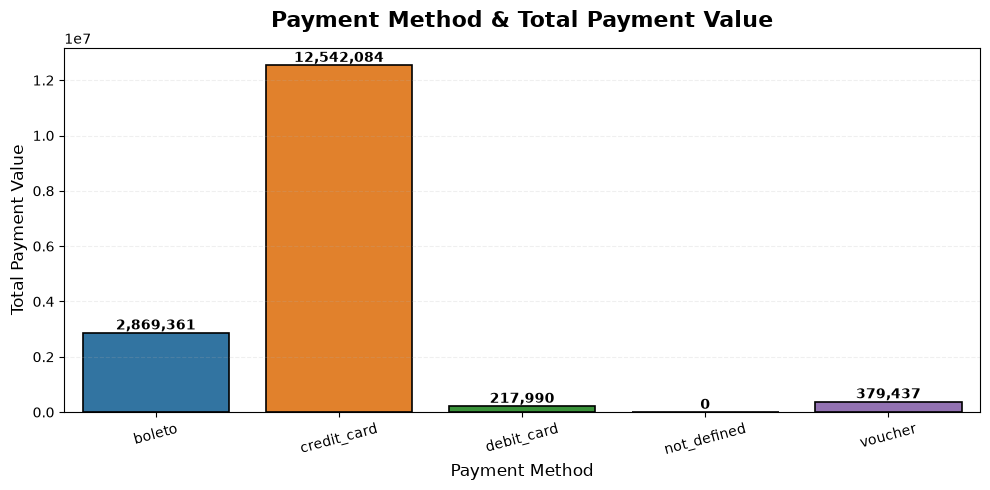

In [43]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=payment_by_method.index,
    y=payment_by_method.values,
    hue=payment_by_method.index,
    legend=False,
    edgecolor='black',
    linewidth=1.2
)

for i, value in enumerate(payment_by_method.values):
    ax.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Payment Method & Total Payment Value', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Total Payment Value', fontsize=12)

plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

# Seller Analysis

In [44]:
seller_orders = order_item['seller_id'].value_counts().head(10)

In [45]:
seller_order_count = order_item.groupby('seller_id')['order_id'].nunique().sort_values(ascending=False).head(10)
seller_order_count

seller_id
6560211a19b47992c3666cc44a7e94c0    1854
4a3ca9315b744ce9f8e9374361493884    1806
cc419e0650a3c5ba77189a1882b7556a    1706
1f50f920176fa81dab994f9023523100    1404
da8622b14eb17ae2831f4ac5b9dab84a    1314
955fee9216a65b617aa5c0531780ce60    1287
7a67c85e85bb2ce8582c35f2203ad736    1160
ea8482cd71df3c1969d7b9473ff13abc    1146
4869f7a5dfa277a7dca6462dcf3b52b2    1132
3d871de0142ce09b7081e2b9d1733cb1    1080
Name: order_id, dtype: int64

In [46]:
seller_sales = order_item.groupby('seller_id')['price'].sum().sort_values(ascending=False).head(10)

# Seller Distribution

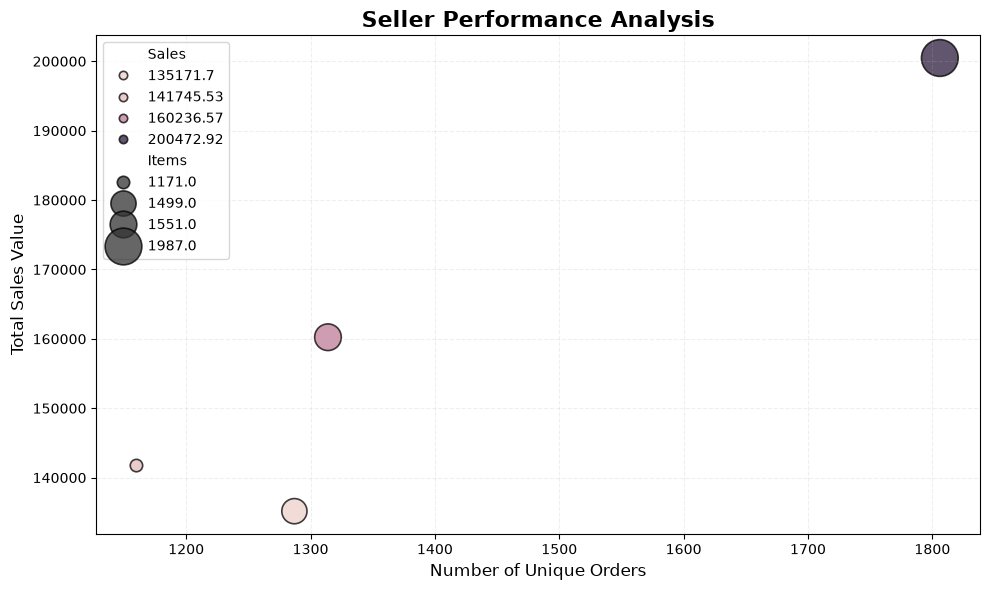

In [47]:
seller_data = pd.DataFrame({
    'Items': seller_orders,
    'Orders': seller_order_count,
    'Sales': seller_sales
}).dropna()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=seller_data,
    x='Orders',
    y='Sales',
    size='Items',
    hue='Sales',
    sizes=(80, 700),
    alpha=0.75,
    edgecolor='black',
    linewidth=1.2
)

plt.title('Seller Performance Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Number of Unique Orders', fontsize=12)
plt.ylabel('Total Sales Value', fontsize=12)

plt.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

# Customer Segmentation(RFM)

In [48]:
# Customer Data Combine

customer_data = orders.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id'
)

customer_data = customer_data.merge(
    payments[['order_id', 'payment_value']],
    on='order_id'
)

customer_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,customer_unique_id,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8.0,7c396fd4830fd04220f754e42b4e5bff,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8.0,7c396fd4830fd04220f754e42b4e5bff,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8.0,7c396fd4830fd04220f754e42b4e5bff,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13.0,af07308b275d755c9edb36a90c618231,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9.0,3a653a41f6f9fc3d2a113cf8398680e8,179.12


# Recency Orders

In [49]:
customer_data['order_purchase_timestamp'] = pd.to_datetime(
    customer_data['order_purchase_timestamp']
)

reference_date = customer_data['order_purchase_timestamp'].max()

reference_date

Timestamp('2018-10-17 17:30:18')

# Frequency 

In [50]:
customer_data = pd.merge(
    customers,
    orders,
    on='customer_id',
    how='inner'
)

In [51]:
customer_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,8.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,16.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,26.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,14.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,11.0


In [52]:
frequency_order = customer_data.groupby(
    'customer_unique_id'
)['order_id'].nunique().reset_index()

frequency_order.head()

,customer_unique_id,order_id
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


# Monetary

In [53]:
order_item.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [54]:
monetary_data = pd.merge(
    customer_data,
    order_item,
    on='order_id',
    how='inner'
)

In [55]:
monetary_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,8.0,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,16.0,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,26.0,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,14.0,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,11.0,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25


# Recency Score For Customers

In [56]:
recency_order = customer_data.groupby(
    'customer_unique_id'
)['order_purchase_timestamp'].max().reset_index()

In [57]:
recency_order['Recency'] = (
    customer_data['order_purchase_timestamp'].max()
    - recency_order['order_purchase_timestamp']
).dt.days

In [58]:
recency_order.head()

,customer_unique_id,order_purchase_timestamp,Recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,163
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,585
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,369
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,336


In [59]:
recency_order['R_Score'] = pd.qcut(
    recency_order['Recency'],
    5,
    labels=[5, 4, 3, 2, 1]
)

# Frequency Score

In [60]:
frequency_order['F_Score'] = pd.qcut(
    frequency_order['order_id'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

# Monetary Score

In [61]:
monetary_order = monetary_data.groupby(
    'customer_unique_id'
)['price'].sum().reset_index()

In [62]:
monetary_order.head()

,customer_unique_id,price
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90
2,0000f46a3911fa3c0805444483337064,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,25.99
4,0004aac84e0df4da2b147fca70cf8255,180.00


In [63]:
monetary_order['M_Score'] = pd.qcut(
    monetary_order['price'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [64]:
rfm = recency_order[['customer_unique_id', 'R_Score']].merge(
    frequency_order[['customer_unique_id', 'F_Score']],
    on='customer_unique_id'
).merge(
    monetary_order[['customer_unique_id', 'M_Score']],
    on='customer_unique_id'
)

In [65]:
def segment(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Best & Loyal Customer'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 2 and row['M_Score'] >= 2:
        return 'Potential Loyal Customer'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk Customer'
    else:
        return 'Lost Customer'

In [66]:
rfm['Customer_Segment'] = rfm.apply(segment, axis=1)

In [67]:
rfm.head()

,customer_unique_id,R_Score,F_Score,M_Score,Customer_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,4,1,4,Lost Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,4,1,1,Lost Customer
2,0000f46a3911fa3c0805444483337064,1,1,2,Lost Customer
3,0000f6ccb0745a6a4b88665a16c9f078,2,1,1,Lost Customer
4,0004aac84e0df4da2b147fca70cf8255,2,1,5,Lost Customer


In [68]:
rfm["Customer_Segment"].value_counts()

Customer_Segment
Lost Customer               35806
Potential Loyal Customer    30233
At Risk Customer            22690
Best & Loyal Customer        6691
Name: count, dtype: int64

# Customer Segment Distribution

C:\Users\acer\AppData\Local\Temp\ipykernel_5372\1776039227.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


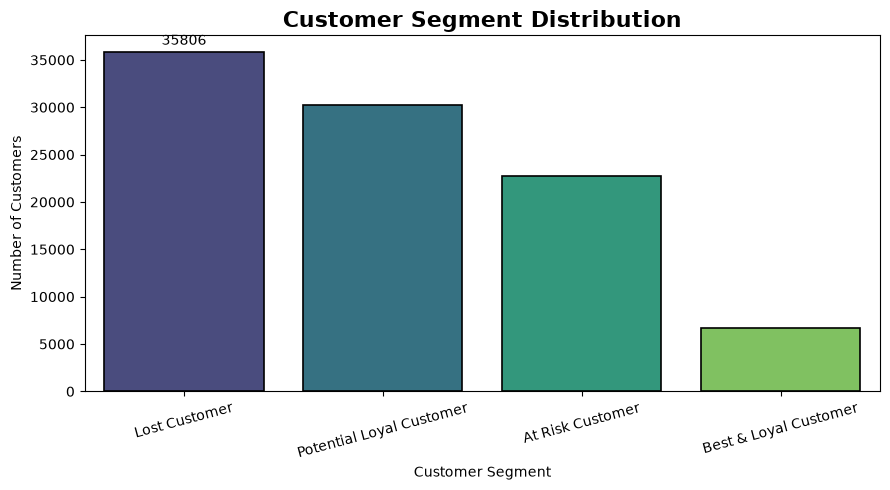

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

segment_counts = rfm['Customer_Segment'].value_counts()

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    palette='viridis',
    edgecolor='black',
    linewidth=1.2
)

ax.bar_label(ax.containers[0], padding=3)

plt.title('Customer Segment Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Dashboard Creation

The dashboard presents important business insights in one place. It combines sales, customer, product, and delivery analysis to understand overall business performance.

# Key Performance Indicators (KPI)

In [70]:
total_customers = customer_data['customer_unique_id'].nunique()

print("Total Customers:", total_customers)

Total Customers: 96096


# Total Orders

In [71]:
total_orders = customer_data['order_id'].nunique()

print("Total Orders:", total_orders)

Total Orders: 99441


# Delivery Rate

In [72]:
total_orders = customer_data['order_id'].nunique()

delivered_orders = customer_data['order_delivered_customer_date'].notna().sum()

delivery_rate = (delivered_orders / total_orders) * 100

print("Delivery Rate:", delivery_rate, "%")

Delivery Rate: 97.01833247855512 %


#  Average Delivery Delay

In [73]:
average_delay = customer_data['delivery_days'].mean()

print("Average Delivery Delay:", average_delay, "days")

Average Delivery Delay: 12.094085575687217 days


# Sales Overview

In [74]:
customer_data['order_purchase_timestamp'] = pd.to_datetime(
    customer_data['order_purchase_timestamp']
)

customer_data['month'] = customer_data['order_purchase_timestamp'].dt.month

In [75]:
monthly_sales = customer_data.groupby('month')['delivery_days'].count()

print(monthly_sales)

month
1      7819
2      8209
3      9549
4      9101
5     10294
6      9231
7     10028
8     10544
9      4151
10     4748
11     7288
12     5514
Name: delivery_days, dtype: int64


# Monthly Orders Trend

In [76]:
monthly_orders = customer_data.groupby('month')['order_id'].count()

print(monthly_orders)

month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: order_id, dtype: int64


# Average Orders Per Month

In [77]:
average_monthly_orders = monthly_orders.mean()

print(average_monthly_orders)

8286.75


In [78]:
data.shape

(71, 2)

# Sales Performance & Customer Analysis Dashboard

In [79]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 10))

fig.suptitle(
    'Sales Performance & Customer Analysis Dashboard',
    fontsize=20,
    fontweight='bold'
)

plt.show()

<Figure size 1600x1000 with 0 Axes>

In [80]:
# KPI Cards layout

ax1 = fig.add_axes([0.05, 0.78, 0.28, 0.10])
ax2 = fig.add_axes([0.36, 0.78, 0.28, 0.10])
ax3 = fig.add_axes([0.67, 0.78, 0.28, 0.10])

ax1.axis('off')
ax2.axis('off')
ax3.axis('off')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

In [81]:
ax1.text(0.5, 0.5, 'Total Orders\nVALUE',
         ha='center', va='center', fontsize=16, fontweight='bold')

ax2.text(0.5, 0.5, 'Delivery Rate\nVALUE',
         ha='center', va='center', fontsize=16, fontweight='bold')

ax3.text(0.5, 0.5, 'Average Delivery\nVALUE',
         ha='center', va='center', fontsize=16, fontweight='bold')

Text(0.5, 0.5, 'Average Delivery\nVALUE')

In [82]:
ax1.text(0.5, 0.6, '99,441',
         ha='center', va='center',
         fontsize=20, fontweight='bold')

ax1.text(0.5, 0.2, 'Total Orders',
         ha='center', va='center',
         fontsize=11)

ax2.text(0.5, 0.6, '97.02%',
         ha='center', va='center',
         fontsize=20, fontweight='bold')

ax2.text(0.5, 0.2, 'Delivery Rate',
         ha='center', va='center',
         fontsize=11)

ax3.text(0.5, 0.6, '12.09 days',
         ha='center', va='center',
         fontsize=20, fontweight='bold')

ax3.text(0.5, 0.2, 'Average Delivery Delay',
         ha='center', va='center',
         fontsize=11)

plt.show()

# Sales Overview Heading

In [83]:
ax4 = fig.add_axes([0.05, 0.58, 0.58, 0.16])

ax4.set_title(
    'Sales Overview',
    fontsize=14,
    fontweight='bold'
)

ax4.axis('off')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

In [84]:
# Create Monthly Revenue

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

monthly_revenue = orders.merge(
    order_item[['order_id', 'price']],
    on='order_id',
    how='left'
)

monthly_revenue['Month'] = (
    monthly_revenue['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

monthly_revenue = monthly_revenue.groupby(
    'Month'
)['price'].sum()

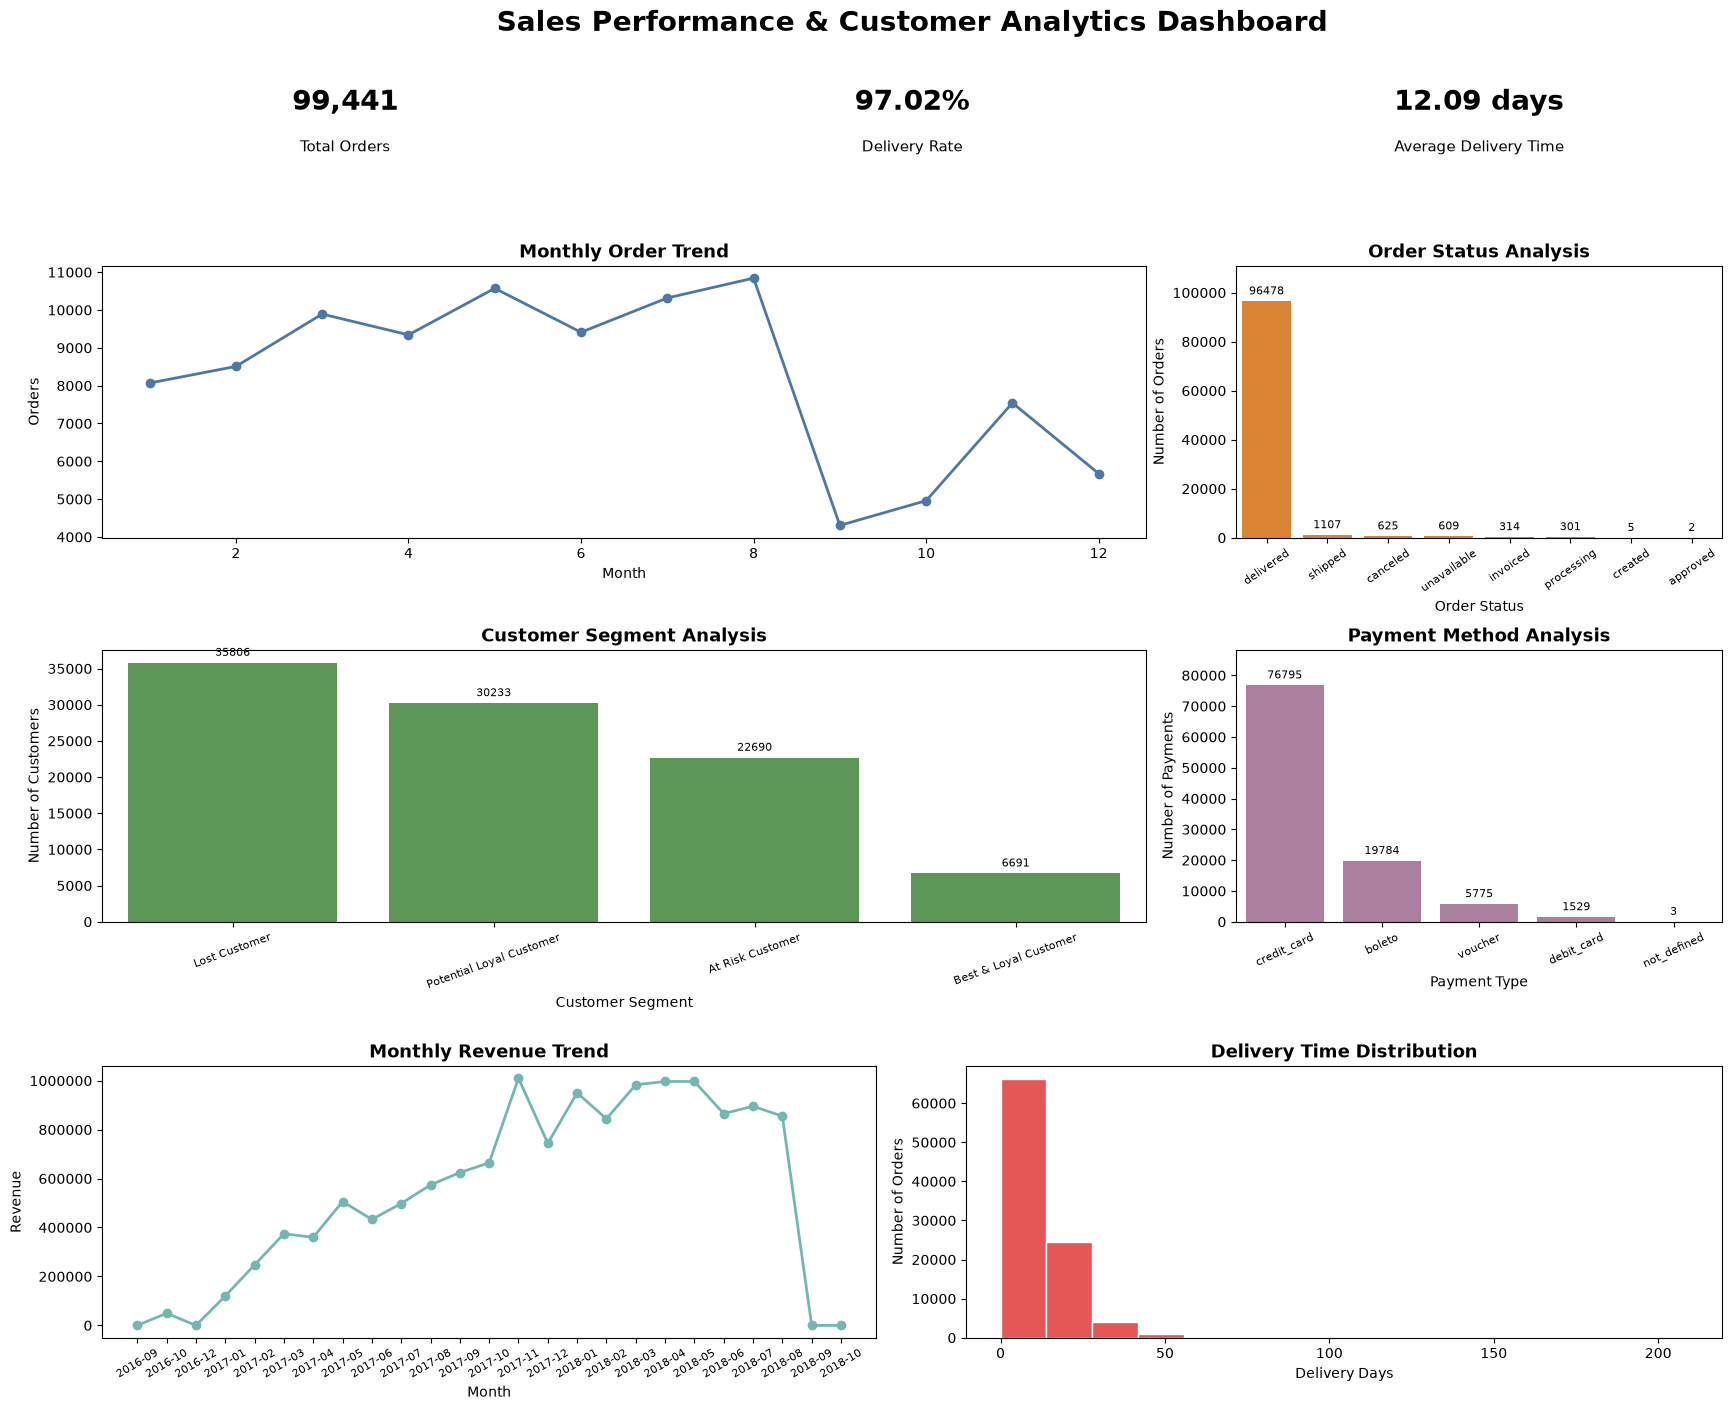

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns


# CREATE DASHBOARD CANVAS

fig = plt.figure(figsize=(18, 16))

fig.suptitle(
    'Sales Performance & Customer Analytics Dashboard',
    fontsize=20,
    fontweight='bold',
    y=0.97
)

# COLORS

blue = '#4C78A8'
orange = '#F58518'
green = '#54A24B'
red = '#E45756'
purple = '#B279A2'
teal = '#72B7B2'


# KPI CARDS

ax1 = fig.add_axes([0.05, 0.87, 0.27, 0.07])
ax2 = fig.add_axes([0.365, 0.87, 0.27, 0.07])
ax3 = fig.add_axes([0.68, 0.87, 0.27, 0.07])

ax1.axis('off')
ax2.axis('off')
ax3.axis('off')

ax1.text(0.5, 0.6, '99,441',
         ha='center', va='center',
         fontsize=20, fontweight='bold')

ax1.text(0.5, 0.2, 'Total Orders',
         ha='center', va='center',
         fontsize=11)

ax2.text(0.5, 0.6, '97.02%',
         ha='center', va='center',
         fontsize=20, fontweight='bold')

ax2.text(0.5, 0.2, 'Delivery Rate',
         ha='center', va='center',
         fontsize=11)

ax3.text(0.5, 0.6, '12.09 days',
         ha='center', va='center',
         fontsize=20, fontweight='bold')

ax3.text(0.5, 0.2, 'Average Delivery Time',
         ha='center', va='center',
         fontsize=11)


# MONTHLY ORDER TREND

ax4 = fig.add_axes([0.05, 0.64, 0.58, 0.17])

ax4.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker='o',
    linewidth=2,
    color=blue
)

ax4.set_title(
    'Monthly Order Trend',
    fontsize=13,
    fontweight='bold'
)

ax4.set_xlabel('Month')
ax4.set_ylabel('Orders')


# ORDER STATUS ANALYSIS

status_counts = orders['order_status'].value_counts()

ax5 = fig.add_axes([0.68, 0.64, 0.27, 0.17])

status_bars = sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    ax=ax5,
    color=orange
)

ax5.set_title(
    'Order Status Analysis',
    fontsize=13,
    fontweight='bold'
)

ax5.set_xlabel('Order Status')
ax5.set_ylabel('Number of Orders')

ax5.tick_params(
    axis='x',
    rotation=35,
    labelsize=8
)

# EXTRA SPACE FOR BAR LABELS
ax5.margins(y=0.15)

ax5.bar_label(
    ax5.containers[0],
    fmt='%d',
    padding=3,
    fontsize=8
)


# CUSTOMER SEGMENT ANALYSIS

segment_counts = rfm['Customer_Segment'].value_counts()

ax7 = fig.add_axes([0.05, 0.40, 0.58, 0.17])

segment_bars = sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    ax=ax7,
    color=green
)

ax7.set_title(
    'Customer Segment Analysis',
    fontsize=13,
    fontweight='bold'
)

ax7.set_xlabel('Customer Segment')
ax7.set_ylabel('Number of Customers')

ax7.tick_params(
    axis='x',
    rotation=20,
    labelsize=8
)

ax7.bar_label(
    ax7.containers[0],
    fmt='%d',
    padding=3,
    fontsize=8
)


# PAYMENT METHOD ANALYSIS

payment_counts = payments['payment_type'].value_counts()

ax6 = fig.add_axes([0.68, 0.40, 0.27, 0.17])

payment_bars = sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values,
    ax=ax6,
    color=purple
)

ax6.set_title(
    'Payment Method Analysis',
    fontsize=13,
    fontweight='bold'
)

ax6.set_xlabel('Payment Type')
ax6.set_ylabel('Number of Payments')

ax6.tick_params(
    axis='x',
    rotation=25,
    labelsize=8
)

# EXTRA SPACE FOR BAR LABELS
ax6.margins(y=0.15)

ax6.bar_label(
    ax6.containers[0],
    fmt='%d',
    padding=3,
    fontsize=8
)


# MONTHLY REVENUE TREND

ax8 = fig.add_axes([0.05, 0.14, 0.43, 0.17])

ax8.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker='o',
    linewidth=2,
    color=teal
)

ax8.set_title(
    'Monthly Revenue Trend',
    fontsize=13,
    fontweight='bold'
)

ax8.set_xlabel('Month')
ax8.set_ylabel('Revenue')

ax8.tick_params(
    axis='x',
    rotation=30,
    labelsize=8
)

ax8.ticklabel_format(
    style='plain',
    axis='y'
)


# DELIVERY TIME DISTRIBUTION

ax10 = fig.add_axes([0.53, 0.14, 0.42, 0.17])

ax10.hist(
    orders['delivery_days'].dropna(),
    bins=15,
    color=red,
    edgecolor='white'
)

ax10.set_title(
    'Delivery Time Distribution',
    fontsize=13,
    fontweight='bold'
)

ax10.set_xlabel('Delivery Days')
ax10.set_ylabel('Number of Orders')


# FINAL LAYOUT

plt.show()